# Predicting trip durations

A simple machine learning workflow featuring various regression models.

## Data loading and logging config

A bit of a overengineering here but setting up logging for *best practices* and bit of a self-recap.

In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

In [112]:
import pickle
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

Load the datasets into the session.

In [3]:
train_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet"
valid_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet"

try:
    current_path = train_data_path
    train_data = pd.read_parquet(train_data_path)
    logging.info(f"Dataset {train_data_path} sucessfully loaded.")
    
    current_path = valid_data_path
    valid_data = pd.read_parquet(valid_data_path)
    logging.info(f"Dataset {valid_data_path} sucessfully loaded.")
    
except HTTPError as e:
    logging.error(f"HTTP Error {e.code}: The file was not found at {current_path}.")
    
except URLError as e:
    logging.critical(f"Network Connection Error at {current_path}: Could not resolve the server. Reason: {e.reason}")
    
except Exception as e:
    logging.error(f"An unexpected error occurred while reading {current_path}: {e}")

2026-09-12 15:53:12 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet sucessfully loaded.
2026-09-12 15:53:12 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet sucessfully loaded.


## Notes (in chronological order)

- Feature engineer the target variable `trip_duration` from dropoff and pickup datetime variables
  - Duration is converted to minutes (`td.total_seconds / 60`)
- Filter trip durations between 1 to 60 minutes
  - After checking distribution, decided to only keep data up to the ~99th percentile (68.453 mins)
  - Model will only capture trip durations of at least a minute up to an hour
- Select numerical and categorical features
  - LocationIDs (`PU` and `DO`) are concatenated to form a combination `trip_id` feature
  - `trip_distance` was not used here since it is an *a posteriori* feature, something that is only determined after the trip
- Encode the categorical features with 1h-encoding via `ColumnTransformer`
  - `ColumnTransformer` for standard `scikit-learn` production pipelines, better handling of schema and drift errors. It also natively handles the `DataFrame`.
  - `DictVectorizer` for row-by-row streaming (native JSON/dict support) from Kafka, Kinesis, or an endpoint, looser handling of schema and may silently shift features. Additionally, converting a `DataFrame` to a dictionary is inefficient.
- Fit linear, lasso, and ridge regression models on the training/validation data
  - Visualise prediction distributions against the training/validation data
  - Calculate RMSE and relative error (rRMSE) scores for each
- Save transformer and linreg model with `pickle`

In [4]:
train_data["trip_duration"] = train_data["lpep_dropoff_datetime"] - train_data["lpep_pickup_datetime"]
train_data.trip_duration = round(train_data.trip_duration.dt.total_seconds() / 60, 3)

In [5]:
train_data.trip_duration.quantile([.25, .5, .75, .9, .95, .99])

0.25     7.0000
0.50    11.5830
0.75    18.2000
0.90    27.3330
0.95    35.4381
0.99    68.4530
Name: trip_duration, dtype: float64

In [6]:
df = train_data[(train_data.trip_duration >= 1) & (train_data.trip_duration <= 60)]

In [7]:
# numerical = ['trip_distance']  is a posteriori feature and will contribute to data leakage
df["pickup_hour"] = df.lpep_pickup_datetime.dt.hour
df["day_of_week"] = df.lpep_pickup_datetime.dt.day_of_week
df["day_of_month"] = df.lpep_pickup_datetime.dt.month

df["trip_id"] = df.PULocationID.astype(str) + "_" + df.DOLocationID.astype(str)

In [8]:
num_features = ["pickup_hour", "day_of_week", "day_of_month"]
cat_features = ["trip_id"]

Two options below for one-hot encoding:

In [9]:
# train_dicts = df[num_features + cat_features].to_dict(orient='records')
# dv = DictVectorizer()
# train_array = dv.fit_transform(train_dicts)

In [23]:
transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat_features),
        ('num', "passthrough", num_features)
    ]
)

In [24]:
X_train = transformer.fit_transform(df)

In [12]:
target = "trip_duration"
y_train = df[target].values

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6685,)","[28.87,12.46,11.62,...,-0.01,-0.24,-0.34]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6685


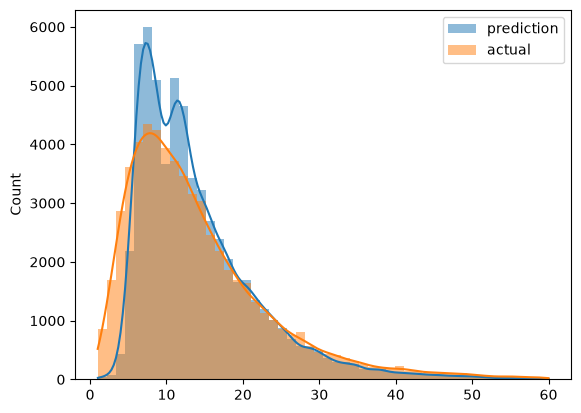

In [14]:
train_pred = lr.predict(X_train)

sns.histplot(train_pred, label="prediction", bins=50, kde=True, edgecolor=None)
sns.histplot(y_train, label="actual", bins=50, kde=True, edgecolor=None)
plt.legend()
plt.show()

Calculate RMSE of predictions on the training data:

In [15]:
root_mean_squared_error(train_pred, y_train)

4.978029819647843

In [67]:
def read_dataframe(filename: str) -> pd.DataFrame:
    try:
        if not (filename.endswith(".csv") or filename.endswith(".parquet")):
            e = f"Unsupported file format for {filename}. Must be .csv or .parquet."
            logging.error(e)
            raise ValueError(e)
        
        if filename.endswith(".csv"):
            df = pd.read_csv(filename)

            # datetime features in csv files are not automatically parsed
            df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
            df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
        
        elif filename.endswith(".parquet"):
            df = pd.read_parquet(filename)
        
        logging.info(f"Dataset {filename} sucessfully loaded.")
        
        df["trip_duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
        df.trip_duration = df.trip_duration.apply(lambda td: td.total_seconds() / 60)
        logging.info(f"Duration feature succesfully created.")
        
        df = df[(df.trip_duration >= 1) & (df.trip_duration <= 60)]

        df["pickup_hour"] = df.lpep_pickup_datetime.dt.hour
        df["day_of_week"] = df.lpep_pickup_datetime.dt.dayofweek
        df["day_of_month"] = df.lpep_pickup_datetime.dt.day
        df["trip_id"] = df.PULocationID.astype(str) + "_" + df.DOLocationID.astype(str)
        
        return df
        
    except HTTPError as e:
        logging.error(f"HTTP Error {e.code}: The file was not found at {filename}.")
        raise
        
    except URLError as e:
        logging.critical(f"Network Connection Error at {filename}: Could not resolve the server. Reason: {e.reason}")
        raise
        
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading {filename}: {e}")
        raise


def process(
    train_data: pd.DataFrame, 
    valid_data: pd.DataFrame, 
    cat_features: list[str], 
    num_features: list[str],
    target: str = "trip_duration"
) -> tuple[object, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    
    transformer = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown="ignore"), cat_features),
            ('num', "passthrough", num_features)
        ]
    )
    logging.info("ColumnTransformer initialised with OneHotEncoder.")
    
    X_train_raw = train_data[cat_features + num_features]
    X_valid_raw = valid_data[cat_features + num_features]
    
    y_train = train_data[target].values
    y_valid = valid_data[target].values

    X_train = transformer.fit_transform(X_train_raw)
    logging.info("Transformer successfully fit and transformed training data.")
    X_valid = transformer.transform(X_valid_raw)
    logging.info("Validation data successfully transformed.")

    return transformer, X_train, y_train, X_valid, y_valid


def plot_dist(title, pred, actual):
    sns.histplot(pred, label="prediction", bins=50, kde=True, edgecolor=None)
    sns.histplot(actual, label="actual", bins=50, kde=True, edgecolor=None)
    plt.title(title)
    plt.legend()
    plt.show()

In [27]:
train_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet"
valid_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet"

train_data = read_dataframe(train_data_path)
valid_data = read_dataframe(valid_data_path)

2026-09-12 15:54:11 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet sucessfully loaded.
2026-09-12 15:54:11 [INFO] Duration feature succesfully created.
2026-09-12 15:54:11 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet sucessfully loaded.
2026-09-12 15:54:11 [INFO] Duration feature succesfully created.


In [28]:
num_features = ["pickup_hour", "day_of_week", "day_of_month"]
cat_features = ["trip_id"]

transformer, X_train, y_train, X_valid, y_valid = process(
    train_data=train_data, 
    valid_data=valid_data, 
    cat_features=cat_features, 
    num_features=num_features,
)

2026-09-12 15:54:12 [INFO] ColumnTransformer initialised with OneHotEncoder.
2026-09-12 15:54:12 [INFO] Transformer successfully fit and transformed training data.
2026-09-12 15:54:13 [INFO] Validation data successfully transformed.


In [139]:
def run_model(model, X, y):
    logging.info(f"Starting: model <{model}> run")
    model.fit(X, y)
    logging.info(f"Model successfully fit to the data.")
    pred = model.predict(X_valid)
    logging.info(f"Model predictions generated.")
    rmse = root_mean_squared_error(y_valid, pred)
    rrmse = round(rmse / y_valid.mean(), 4)
    logging.info(f"Prediction metrics generated.")
    return pred, rmse, rrmse

In [140]:
linreg = LinearRegression()
lasso = Lasso(alpha=0.001)
ridge = Ridge(alpha=0.001)
summary = {}

for model in (linreg, lasso, ridge):
    pred, rmse, rrmse = run_model(model, X_train, y_train)
    summary[model] = {"pred": pred, "rmse": round(rmse, 4), "rrmse": float(rrmse)*100}

2026-09-12 16:56:40 [INFO] Starting: model <LinearRegression()> run
2026-09-12 16:56:40 [INFO] Model successfully fit to the data.
2026-09-12 16:56:40 [INFO] Model predictions generated.
2026-09-12 16:56:40 [INFO] Prediction metrics generated.
2026-09-12 16:56:40 [INFO] Starting: model <Lasso(alpha=0.001)> run
2026-09-12 16:56:41 [INFO] Model successfully fit to the data.
2026-09-12 16:56:41 [INFO] Model predictions generated.
2026-09-12 16:56:41 [INFO] Prediction metrics generated.
2026-09-12 16:56:41 [INFO] Starting: model <Ridge(alpha=0.001)> run
2026-09-12 16:56:41 [INFO] Model successfully fit to the data.
2026-09-12 16:56:41 [INFO] Model predictions generated.
2026-09-12 16:56:41 [INFO] Prediction metrics generated.


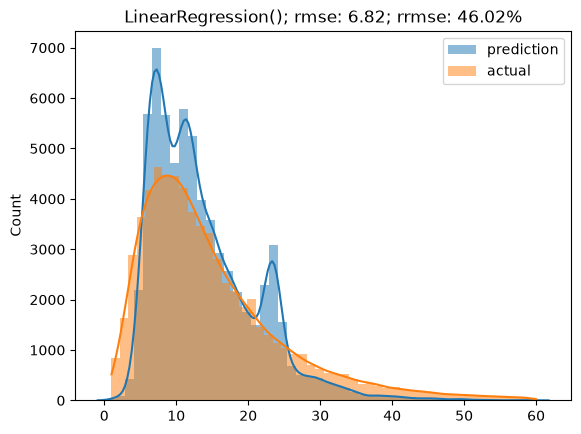

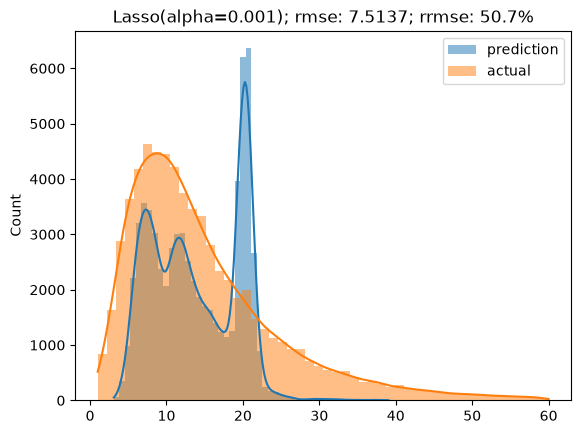

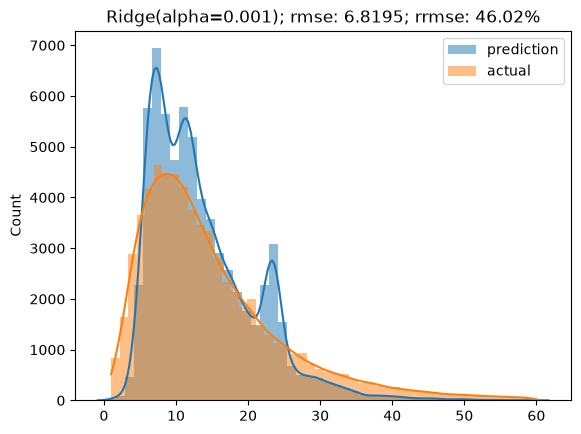

In [141]:
for model in summary:
    plot_dist(
        f"{model}; rmse: {summary[model]["rmse"]}; rrmse: {summary[model]["rrmse"]}%", 
        summary[model]["pred"], 
        y_valid
    )

In [96]:
with open("models/linreg.bin", "wb") as f_out:
    pickle.dump((transformer, linreg), f_out)